In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

# Loading data

In [3]:
import kagglehub
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Path to dataset files:", path)

C:\Users\User\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2


In [4]:
META_PATH = os.path.join(path, 'HAM10000_metadata.csv')
IMG_DIRS = [
    os.path.join(path, 'HAM10000_images_part_1'),
    os.path.join(path, 'HAM10000_images_part_2'),
]

# Load metadata
df = pd.read_csv(META_PATH)

print(f'Rows loaded : {len(df)}')
df.head()

Rows loaded : 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
print("Diagnosis:")
print(df["dx"].unique().tolist())
print("Diagnosis types:")
print(df["dx_type"].unique().tolist())
print("Sex:")
print(df["sex"].unique().tolist())
print("Localization:")
print(df["localization"].unique().tolist())

Diagnosis:
['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']
Diagnosis types:
['histo', 'consensus', 'confocal', 'follow_up']
Sex:
['male', 'female', 'unknown']
Localization:
['scalp', 'ear', 'face', 'back', 'trunk', 'chest', 'upper extremity', 'abdomen', 'unknown', 'lower extremity', 'genital', 'neck', 'hand', 'foot', 'acral']


In [6]:
print('Column types:')
print(df.dtypes)

Column types:
lesion_id        object
image_id         object
dx               object
dx_type          object
age             float64
sex              object
localization     object
dtype: object


# Pre-processing data

In [7]:
LABEL_MAP = {
    'nv'  : 'Melanocytic Nevi',
    'mel' : 'Melanoma',
    'bkl' : 'Benign Keratosis',
    'bcc' : 'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratoses / Intraep. Carcinoma',
    'vasc': 'Vascular Lesions',
    'df'  : 'Dermatofibroma',
}
MALIGNANT = {'mel', 'bcc', 'akiec'} # high-risk

df['dx_full'] = df['dx'].map(LABEL_MAP)
df['malignant'] = df['dx'].isin(MALIGNANT)

In [8]:
# Build image path lookup
image_paths = {}
for d in IMG_DIRS:
    if os.path.isdir(d):
        for fp in glob.glob(os.path.join(d, '*.jpg')):
            image_paths[os.path.splitext(os.path.basename(fp))[0]] = fp

df['image_path'] = df['image_id'].map(image_paths)

print(f'Images found: {df["image_path"].notna().sum()}')
df.head()

Images found: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,dx_full,malignant,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,Benign Keratosis,False,C:\Users\User\.cache\kagglehub\datasets\kmader...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,Benign Keratosis,False,C:\Users\User\.cache\kagglehub\datasets\kmader...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,Benign Keratosis,False,C:\Users\User\.cache\kagglehub\datasets\kmader...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,Benign Keratosis,False,C:\Users\User\.cache\kagglehub\datasets\kmader...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,Benign Keratosis,False,C:\Users\User\.cache\kagglehub\datasets\kmader...


In [9]:
print(f'Unique patients (lesion_id): {df["lesion_id"].nunique()}')
print(f'Unique images IDs: {df["image_id"].nunique()}')
print(f'Diagnosis classes: {df["dx"].nunique()}')
print(F'Shape : {df.shape}')

Unique patients (lesion_id): 7470
Unique images IDs: 10015
Diagnosis classes: 7
Shape : (10015, 10)


In [10]:
print('Missing values:')
missing = df.isnull().sum()
print(missing[missing > 0])

Missing values:
age    57
dtype: int64


In [11]:
df.describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


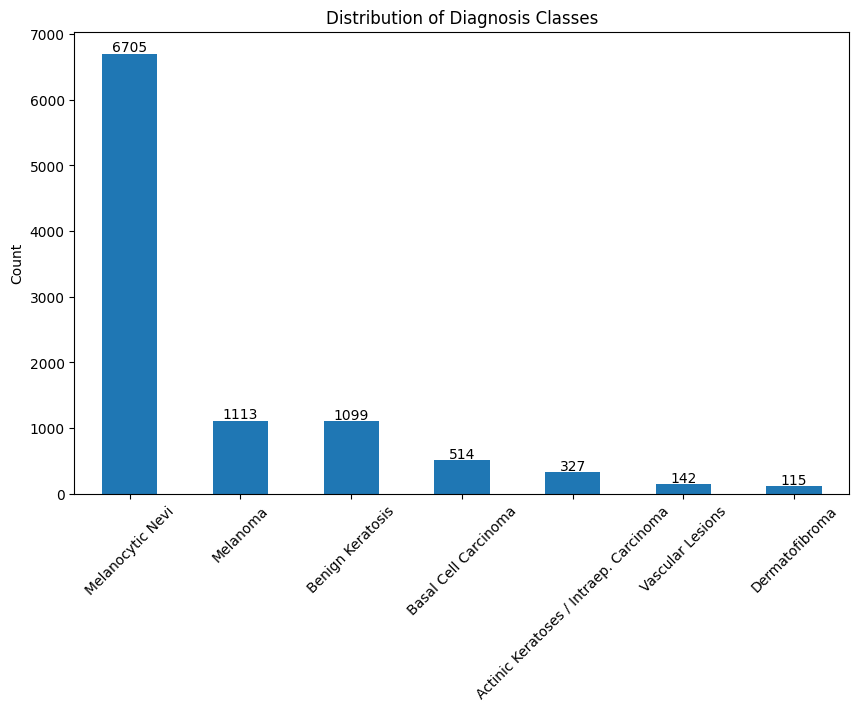

In [12]:
class_counts = df['dx_full'].value_counts()
class_counts.plot(kind='bar', figsize=(10, 6))
plt.title('Distribution of Diagnosis Classes')
plt.xlabel('')
plt.ylabel('Count')
plt.xticks(rotation=45)
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontsize=10)

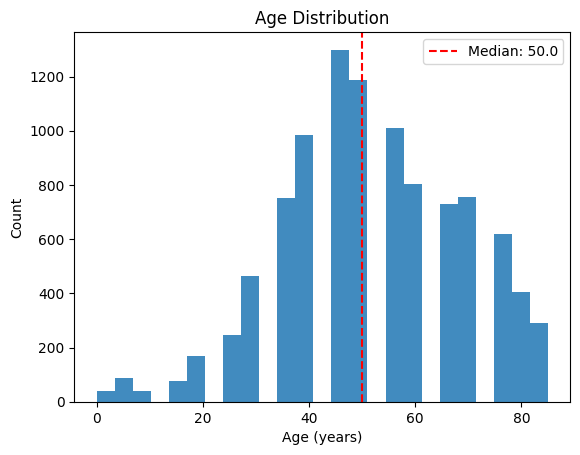

In [13]:
plt.hist(df['age'].dropna(), bins=25, alpha=0.85)
plt.axvline(df['age'].median(), color='red', linestyle='--', label=f'Median: {df["age"].median()}')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.legend()

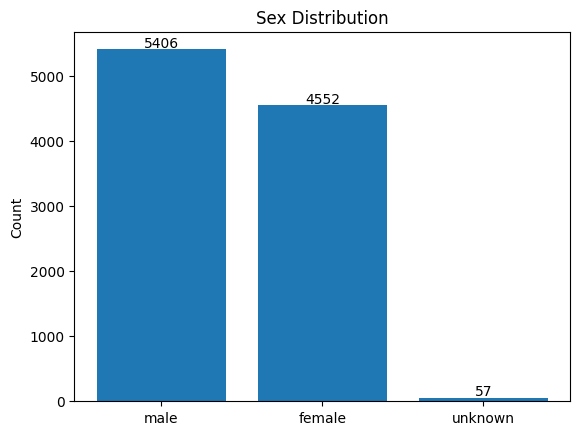

In [14]:
sex_counts = df['sex'].value_counts()
plt.bar(sex_counts.index, sex_counts.values)
plt.title('Sex Distribution')
plt.ylabel('Count')
for i, v in enumerate(sex_counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontsize=10)

Text(0, 0.5, '')

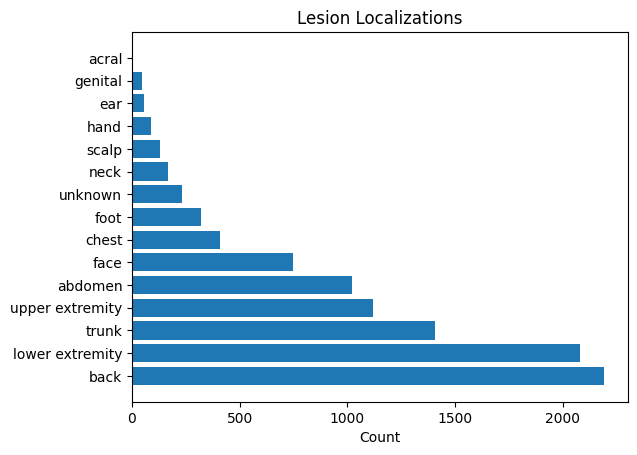

In [15]:
loc_counts = df['localization'].value_counts()
plt.barh(loc_counts.index, loc_counts.values)
plt.title('Lesion Localizations')
plt.xlabel('Count')
plt.ylabel('')

Text(0.5, 1.0, 'Malignant vs Benign Breakdown')

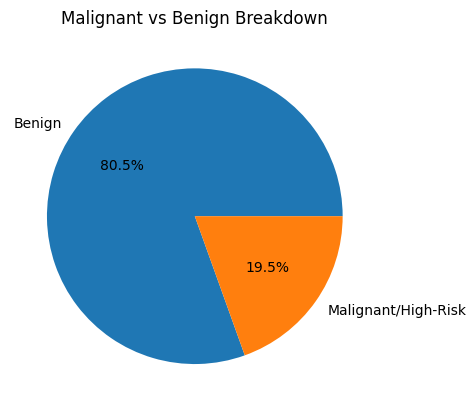

In [16]:
mal_counts = df['malignant'].map({True: 'Malignant/High-Risk', False: 'Benign'}).value_counts()
plt.pie(mal_counts.values, labels=mal_counts.index, autopct='%1.1f%%')
plt.title('Malignant vs Benign Breakdown')

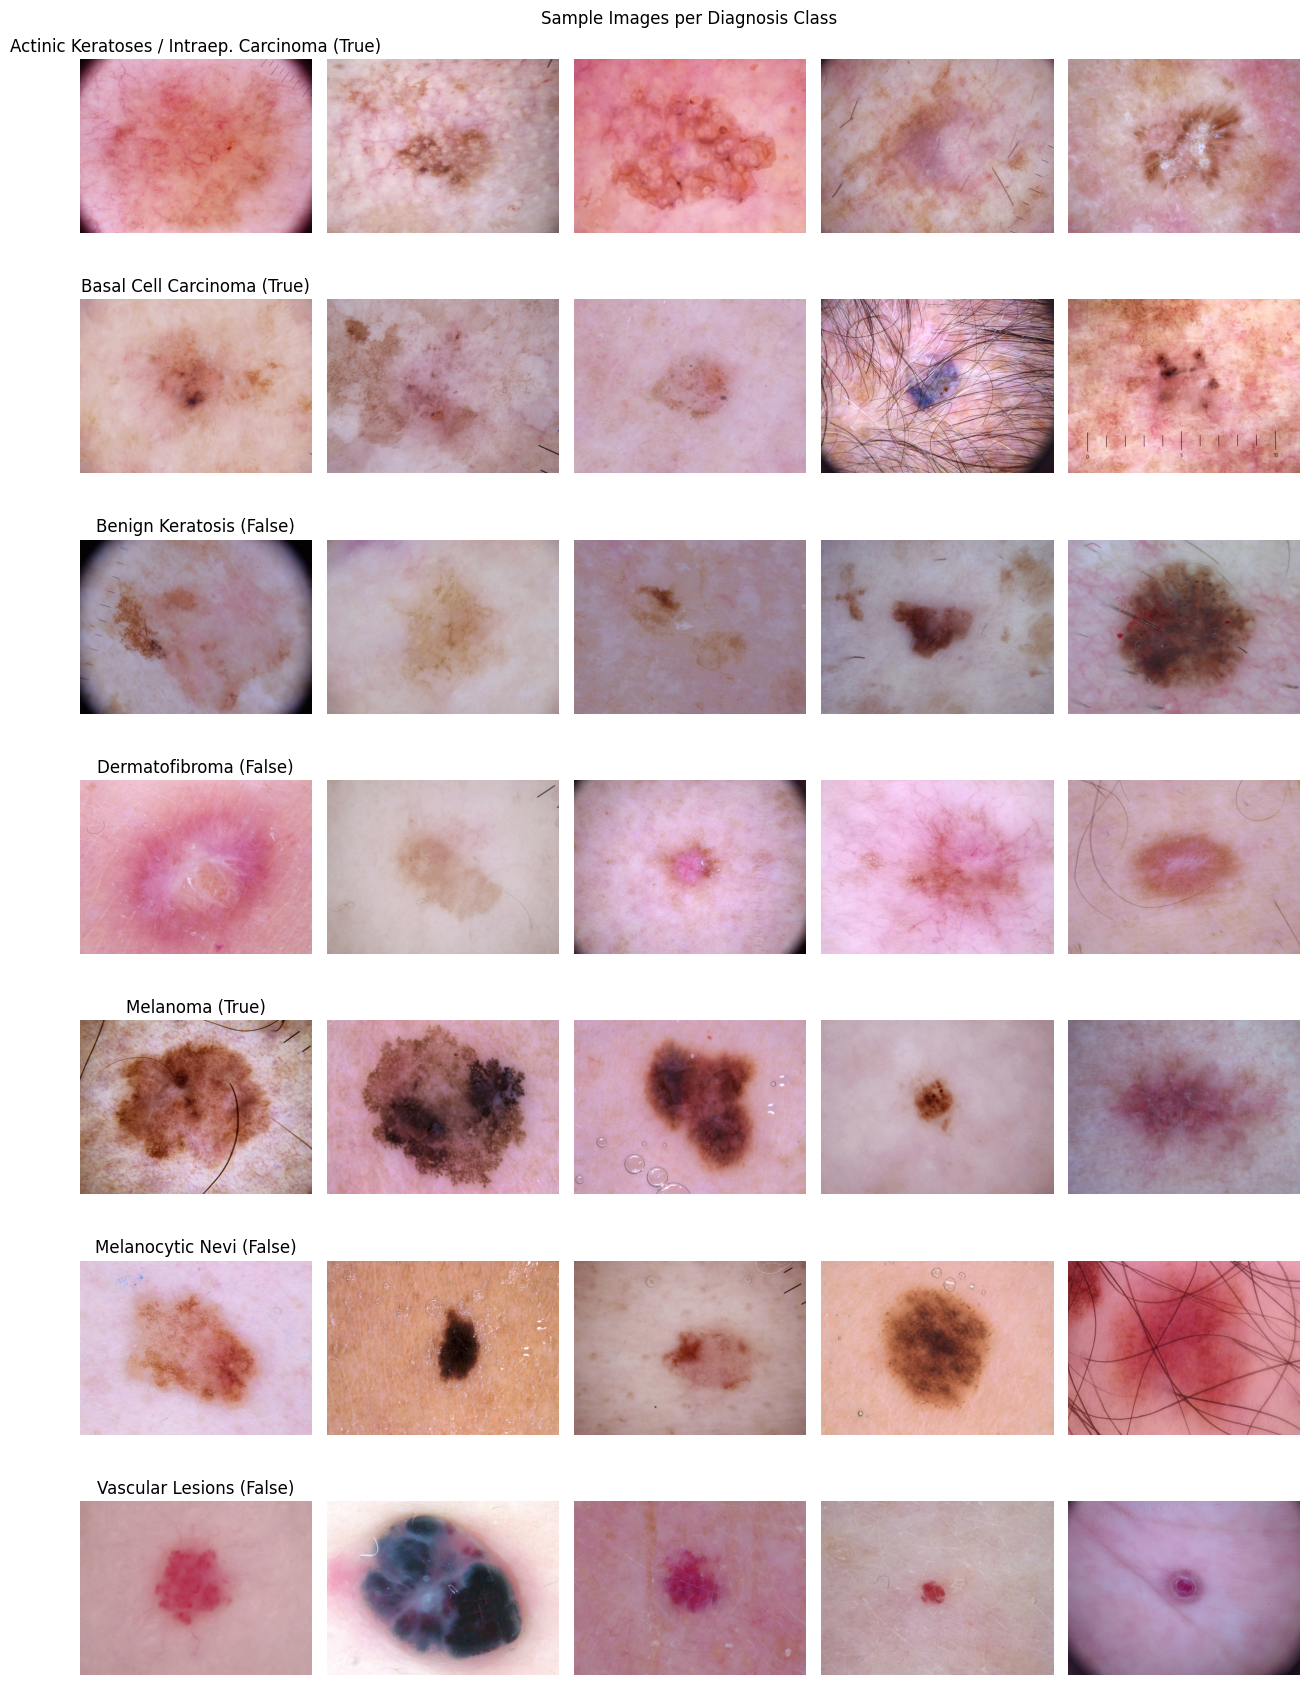

In [17]:

classes = sorted(df['dx'].unique())
n_classes = len(classes)
fig, axes = plt.subplots(n_classes, 5,
    figsize=(5 * 2.5, n_classes * 2.5))

for row_idx, dx in enumerate(classes):
    subset = df[df['dx'] == dx]
    samples = subset.sample(min(5, len(subset)))

    for col_idx in range(5):
        ax = axes[row_idx][col_idx]
        img = Image.open(samples.iloc[col_idx]['image_path'])
        ax.imshow(img)

        ax.axis('off')
        if col_idx == 0:
            m = samples.iloc[col_idx]['malignant']
            ax.set_title(f'{LABEL_MAP[dx]} ({m})')

plt.suptitle('Sample Images per Diagnosis Class')
plt.tight_layout()
plt.show()


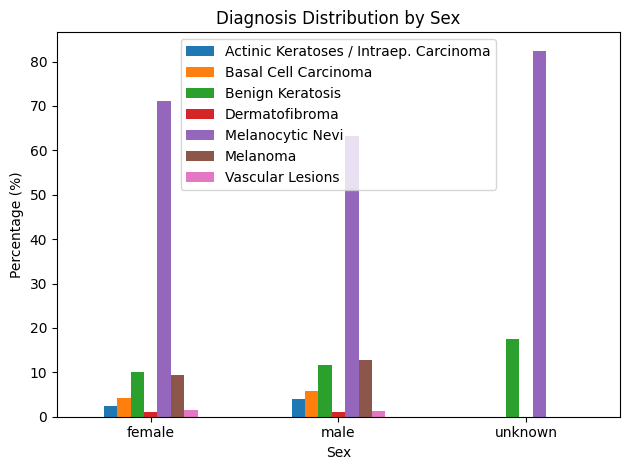

In [18]:
cross = pd.crosstab(df['sex'], df['dx_full'], normalize='index') * 100
cross.plot(kind='bar')
plt.title('Diagnosis Distribution by Sex')
plt.xlabel('Sex')
plt.ylabel('Percentage (%)')
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()

In [19]:
subset = df['image_path'].notna()
records = []
for _, row in df[subset].sample(n=2000).iterrows():
    arr = np.array(Image.open(row['image_path']), dtype=np.float32)
    records.append({
        'dx': row['dx'],
        'brightness': arr.mean(),
        'contrast': arr.std(),
        'width': arr.shape[1],
        'height': arr.shape[0],
    })

df_stat = pd.DataFrame(records)

In [20]:
df_stat.describe()

,brightness,contrast,width,height
count,2000.000000,2000.000000,2000.0,2000.0
mean,160.353745,41.216900,600.0,450.0
std,19.379185,11.578406,0.0,0.0
min,72.842117,10.392344,600.0,450.0
25%,147.464409,31.935033,600.0,450.0
50%,160.575424,42.419939,600.0,450.0
75%,172.981716,49.744781,600.0,450.0
max,226.432617,81.279411,600.0,450.0


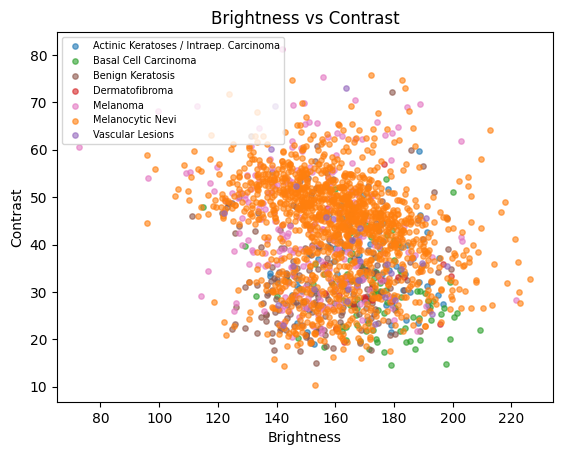

In [21]:
palette = dict(zip(df_stat['dx'].unique(),
                       sns.color_palette('tab10', df_stat['dx'].nunique())))
for dx_code, grp in df_stat.groupby('dx'):
    plt.scatter(grp['brightness'], grp['contrast'], s=15, alpha=0.6,
                    label=LABEL_MAP[dx_code], color=palette[dx_code])
plt.title('Brightness vs Contrast')
plt.xlabel('Brightness')
plt.ylabel('Contrast')
plt.legend(fontsize=7)

# Data Preperation


In [ ]:
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import numpy as np
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
import cv2

#Data Preperation

IMG_SIZE = 224

#hold images
images = []
#resize each image to 224 x 224 x 3
for i in df['image_path']:
    img = cv2.imread(i)
    
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    images.append(img)

#normalize images
X = np.array(images).astype('float32')


#encode labels
encoder = LabelEncoder()
y = encoder.fit_transform(df['dx'])
y = to_categorical(y, num_classes=7)



# Model and Evaluation

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#Pretrained ResNet50 Model

#Use ResNet's Preprocess Input to input in resnet model
X = preprocess_input(X)

#80/20 split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

labels = np.argmax(y_train, axis=1)

#handle unbbalanced data
weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(weights)) 

model_resnet = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)



#freeze layers
for layer in model_resnet.layers[:30]:
    layer.trainable = False


x = model_resnet.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
output = Dense(7, activation='softmax')(x)


model = models.Model(inputs=model_resnet.input, outputs=output)

#Model Summary
#model.summary()

model.compile(loss='categorical_crossentropy',
              optimizer=Adam(1e-5),
              metrics=['accuracy'])

history = model.fit(x_train[:1000], y_train[:1000],
          epochs=10,
          batch_size=32,
          validation_data=(x_test, y_test))


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 178s 5s/step - accuracy: 0.6230 - loss: 1.1889 - val_accuracy: 0.6695 - val_loss: 2.8669
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7136 - loss: 0.8249

In [ ]:
#save model 
model.save("model_v1.keras")



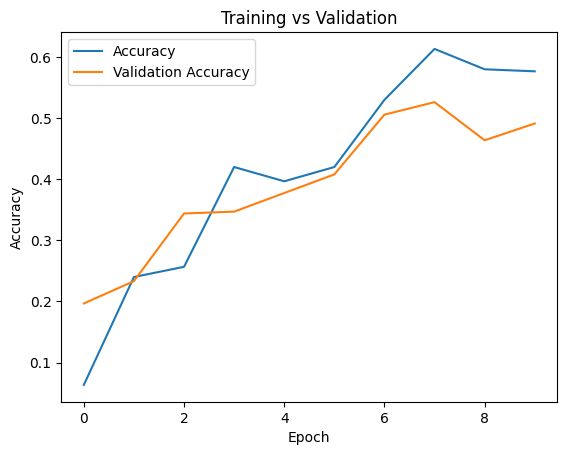

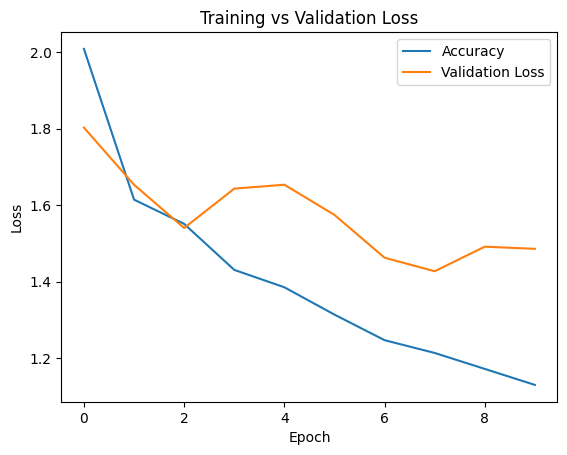

In [ ]:
#Evaluations 

#plot training vs validation
plt.plot(history.history['accuracy'], label="Accuracy")
plt.plot(history.history['val_accuracy'], label="val_acc")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


#plot Training vs Validation Loss
plt.plot(history.history['loss'], label="Accuracy")
plt.plot(history.history['val_loss'], label="val_loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()



63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step


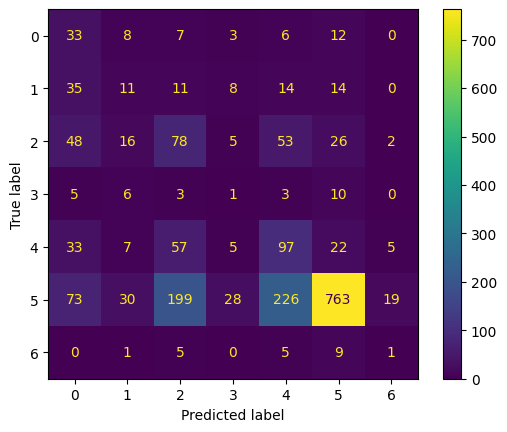

In [ ]:
#confusion matrix
y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred))
cm.plot()
plt.show()